In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import sys
from datetime import datetime

In [2]:
places_csv = pd.read_csv("//depot.engr.oregonstate.edu/mime_u1/dalziel/Safe Graph Data/Weekly Patterns/Digital_Twins_Analysis/Places/2019.csv")

monthly = "//depot.engr.oregonstate.edu/mime_u1/dalziel/Safe Graph Data/Weekly Patterns/Digital_Twins_Analysis/2019/2019_monthly/Newport"
weekly = "//depot.engr.oregonstate.edu/mime_u1/dalziel/Safe Graph Data/Weekly Patterns/Digital_Twins_Analysis/2019/2019_weekly/Newport"

In [3]:
monthly_dfs = [pd.read_csv(path) for path in [os.path.join(monthly, item) for item in os.listdir(monthly)]]
# currently truncated to the first 23 weeks because only 4 intermediate monthly files have been created
weekly_paths = [os.path.join(weekly, item) for item in os.listdir(weekly)]
weekly_dfs = [pd.read_csv(path) for path in weekly_paths]

In [4]:
os.listdir(weekly)[:23]

['week31-2019-07-29.csv',
 'week28-2019-07-08.csv',
 'week13-2019-03-25.csv',
 'week24-2019-06-10.csv',
 'week12-2019-03-18.csv',
 'week3-2019-01-14.csv',
 'week48-2019-11-25.csv',
 'week2-2019-01-07.csv',
 'week27-2019-07-01.csv',
 'week21-2019-05-20.csv',
 'week16-2019-04-15.csv',
 'week9-2019-02-25.csv',
 'week47-2019-11-18.csv',
 'week25-2019-06-17.csv',
 'week26-2019-06-24.csv',
 'week4-2019-01-21.csv',
 'week51-2019-12-16.csv',
 'week14-2019-04-01.csv',
 'week18-2019-04-29.csv',
 'week1-2018-12-31.csv',
 'week38-2019-09-16.csv',
 'week36-2019-09-02.csv',
 'week6-2019-02-04.csv']

In [5]:
monthly_melted = []
for df in monthly_dfs:
    df['month'] = pd.to_datetime(df['date_range_start']).dt.month
    df = df.melt(
        id_vars = ['safegraph_place_id', 'median_dwell', 'month'],
        value_vars = [f"visits_h{i}" for i in range(24)],
        var_name = "hour_of_day",
        value_name = "dwell"
    )
    df['hour_of_day'] = df['hour_of_day'].str.extract(r'(\d+)').astype(int)
    monthly_melted.append(df)

In [6]:
monthly_melted[1]

,safegraph_place_id,median_dwell,month,hour_of_day,dwell
0,sg:d6ee22e287fc4a29b5bcb55053973bba,108.0,1,0,5
1,sg:a711c7a6638b44b4937cdd2177ee212d,8.0,1,0,0
2,sg:90be272ba24d4e7ea06aed27bae751f7,33.0,1,0,5
3,sg:e488c8e89a494897b452ab7432c56f30,53.0,1,0,0
4,sg:4faea969e4b34305a716ec3341a3b422,16.0,1,0,2
...,...,...,...,...,...
9331,sg:f854e584257746458832c2beb2884bba,11.0,1,23,0
9332,sg:90cc0e7ed6ab4201b6c1917a4beefb91,67.0,1,23,76
9333,sg:5a379e6242bc4846a3afbc25a5b679c1,18.0,1,23,11
9334,sg:931db17bc2a845a3a73610bc022e9b09,29.0,1,23,5


In [7]:
import re

for i, df in enumerate(weekly_dfs):
    df['month'] = pd.to_datetime(re.findall(r'week\d{1,2}-([\d-]+).csv',weekly_paths[i])[0]).month

In [8]:
weekly_dfs[0]

,safegraph_place_id,raw_visit_counts,raw_visitor_counts,poi_cbg,distance_from_home,median_dwell,visits_h0,visits_h1,visits_h2,visits_h3,...,d_cbg:270017702001,d_cbg:410530202023,d_cbg:410510048002,d_cbg:484391139272,<5,5-20,21-60,61-240,>240,month
0,sg:83dd7c5b0881400f8b2abcb77c5347bd,5,5,410419511001,5577,50.0,0,0,0,0,...,0,0,0,0,0,2,1,2,0,7
1,sg:0ae6746f4222414ba2bc87422537c351,128,105,410419510002,109219,23.5,0,0,0,0,...,0,0,0,0,1,58,36,24,9,7
2,sg:79fcd454a98c41deb79c9fe68d917fa4,84,52,410419509002,13457,11.5,0,0,0,0,...,0,0,0,0,3,54,12,10,5,7
3,sg:ac4240b60fff40af824309a1557cb020,96,66,410419509004,11809,18.5,0,0,0,0,...,0,0,0,0,1,51,28,9,7,7
4,sg:9973283350f84b84a0bb5b3862f916a3,61,56,410419510002,141774,6.0,0,0,0,0,...,0,0,0,0,3,52,1,4,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,sg:880310f2894744aa8f6b32eec9187f16,60,52,410419511001,21251,30.0,0,0,0,0,...,0,0,4,0,1,21,27,7,4,7
359,sg:ca15f1f15ae547ed8191ea3042a3b88f,24,6,410419509004,5858,50.0,0,0,0,0,...,0,0,0,0,0,10,3,8,3,7
360,sg:c58dbbc7c4fe4436859ad0cbf2a0c96b,34,16,410419509002,10512,55.5,0,0,0,0,...,0,0,0,4,2,11,4,16,1,7
361,sg:f0c9d222e2e74ca3b20db0f6e1a92110,2,2,410419510002,-1,318.5,0,0,0,0,...,0,0,0,0,0,1,0,0,1,7


In [9]:
massive_df = pd.concat(weekly_dfs, ignore_index = True)

In [10]:
weekly_melted = massive_df.melt(
    id_vars = ['safegraph_place_id', 'median_dwell', 'distance_from_home', 'month'],
    value_vars=[f"visits_h{i}" for i in range(168)], 
    var_name='hour_of_week', 
    value_name='arrivals'
)
weekly_melted['hour_of_week'] = weekly_melted['hour_of_week'].str.extract(r'(\d+)').astype(int)
weekly_melted['hour_of_day'] = weekly_melted['hour_of_week']%24

weekly_melted.head(5)

,safegraph_place_id,median_dwell,distance_from_home,month,hour_of_week,arrivals,hour_of_day
0,sg:83dd7c5b0881400f8b2abcb77c5347bd,50.0,5577,7,0,0,0
1,sg:0ae6746f4222414ba2bc87422537c351,23.5,109219,7,0,0,0
2,sg:79fcd454a98c41deb79c9fe68d917fa4,11.5,13457,7,0,0,0
3,sg:ac4240b60fff40af824309a1557cb020,18.5,11809,7,0,0,0
4,sg:9973283350f84b84a0bb5b3862f916a3,6.0,141774,7,0,0,0


In [11]:
weekly_agg = weekly_melted.groupby(['safegraph_place_id','hour_of_day', 'month']).agg({'arrivals':'sum', 'distance_from_home': 'min', 'median_dwell': 'min'})
weekly_agg

arrivals  \
safegraph_place_id                  hour_of_day month             
sg:001e3da6479b40d389529752513d2657 0           1             0   
                                                2             0   
                                                4             0   
                                                5             0   
                                                6             0   
...                                                         ...   
sg:ffadd5fae8c64045b8199d5d4c1838d0 23          7             0   
                                                8             0   
                                                10            0   
                                                11            0   
                                                12            1   

                                                       distance_from_home  \
safegraph_place_id                  hour_of_day month                       
sg:001e3da6479b40d389529752513d2657 0           1                      -1   
                                                2                      -1   
                                                4                      -1   
                                                5                      -1   
                                                6                      -1   
...                                                                   ...   
sg:ffadd5fae8c64045b8199d5d4c1838d0 23          7                      -1   
                                                8                      -1   
                                                10                     -1   
                                                11                     -1   
                                                12                     -1   

                                                       median_dwell  
safegraph_place_id                  hour_of_day month                
sg:001e3da6479b40d389529752513d2657 0           1               6.0  
                                                2              11.0  
                                                4               6.0  
                                                5               5.0  
                                                6               8.0  
...                                                             ...  
sg:ffadd5fae8c64045b8199d5d4c1838d0 23          7              61.0  
                                                8              95.0  
                                                10            455.0  
                                                11             48.0  
                                                12              8.0  

[114048 rows x 3 columns]

In [12]:
weekly_agg = weekly_agg.reset_index(level = ['safegraph_place_id', 'hour_of_day', 'month'])

In [13]:
weekly_agg

,safegraph_place_id,hour_of_day,month,arrivals,distance_from_home,median_dwell
0,sg:001e3da6479b40d389529752513d2657,0,1,0,-1,6.0
1,sg:001e3da6479b40d389529752513d2657,0,2,0,-1,11.0
2,sg:001e3da6479b40d389529752513d2657,0,4,0,-1,6.0
3,sg:001e3da6479b40d389529752513d2657,0,5,0,-1,5.0
4,sg:001e3da6479b40d389529752513d2657,0,6,0,-1,8.0
...,...,...,...,...,...,...
114043,sg:ffadd5fae8c64045b8199d5d4c1838d0,23,7,0,-1,61.0
114044,sg:ffadd5fae8c64045b8199d5d4c1838d0,23,8,0,-1,95.0
114045,sg:ffadd5fae8c64045b8199d5d4c1838d0,23,10,0,-1,455.0
114046,sg:ffadd5fae8c64045b8199d5d4c1838d0,23,11,0,-1,48.0


In [14]:
weekly_agg_subset = weekly_agg[weekly_agg['month'] < 6]

In [15]:
monthly_agg = pd.concat(monthly_melted, ignore_index = False)

In [21]:
dat = weekly_agg_subset.merge(monthly_agg.drop('median_dwell', axis = 1),on=['safegraph_place_id', 'hour_of_day', 'month'])

In [33]:
dat['sin_hod'] = np.sin(2*np.pi*dat['hour_of_day']/24)
dat['cos_hod'] = np.cos(2*np.pi*dat['hour_of_day']/24)

# month is currently 1-12. This is slightly different from hour of day which is 0-23. 
dat['sin_month'] = np.sin(2*np.pi*dat['month']/12)
dat['cos_month'] = np.cos(2*np.pi*dat['month']/12)

# scaling
dat['log_median_dwell'] = np.log(dat['median_dwell'])
dat['median_dwell_hrs'] = dat['median_dwell']/60


In [35]:
# holding out 10% of buildings
builds = dat['safegraph_place_id'].unique()
rng = np.random.default_rng()
test_blds = rng.choice(builds, len(builds)//10)

mask = dat['safegraph_place_id'].isin(test_blds)
tr = dat[~mask]
test = dat[mask]


## MODEL

In [42]:
device = torch.device('gpu' if torch.cuda.is_available() else 'cpu')
tr_sin_hod = torch.tensor(tr['sin_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
tr_cos_hod = torch.tensor(tr['cos_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
tr_arrivals = torch.tensor(tr['arrivals'].values, dtype=torch.float32).unsqueeze(1).to(device)
tr_lmdwell = torch.tensor(tr['log_median_dwell'].values, dtype=torch.float32).unsqueeze(1).to(device)
tr_sin_m = torch.tensor(tr['sin_month'].values, dtype=torch.float32).unsqueeze(1).to(device)
tr_cos_m = torch.tensor(tr['cos_month'].values, dtype=torch.float32).unsqueeze(1).to(device)

tr_y = torch.tensor(tr['dwell'].values, dtype=torch.float32).unsqueeze(1).to(device)


In [49]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        in_dim = 6
        hidden_dim = 64
        out_dim = 1

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
            nn.ReLU()  
        )

    def forward(self, sin_hod, cos_hod, arrivals, dwell, sin_m, cos_m):
        x = torch.cat([sin_hod, cos_hod, arrivals, dwell, sin_m, cos_m], dim=1)
        return self.net(x)

In [50]:
model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [51]:
loss_fn = nn.MSELoss()

In [52]:
num_epochs = 2000
for epoch in range(num_epochs):
    model.train()
    
    optimizer.zero_grad()
    loss = loss_fn(model(tr_sin_hod, tr_cos_hod, tr_arrivals, tr_lmdwell, tr_sin_m, tr_cos_m), tr_y)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")


Epoch 0: loss = 1489.6394
Epoch 50: loss = 514.1821
Epoch 100: loss = 470.7068
Epoch 150: loss = 431.0769
Epoch 200: loss = 398.1811
Epoch 250: loss = 376.5109
Epoch 300: loss = 359.6567
Epoch 350: loss = 345.7845
Epoch 400: loss = 335.4696
Epoch 450: loss = 325.8588
Epoch 500: loss = 316.2882
Epoch 550: loss = 308.0970
Epoch 600: loss = 302.0242
Epoch 650: loss = 296.4982
Epoch 700: loss = 291.1723
Epoch 750: loss = 285.6204
Epoch 800: loss = 281.5954
Epoch 850: loss = 276.5170
Epoch 900: loss = 271.6949
Epoch 950: loss = 267.2849
Epoch 1000: loss = 263.7222
Epoch 1050: loss = 260.5200
Epoch 1100: loss = 258.4155
Epoch 1150: loss = 255.7781
Epoch 1200: loss = 253.8385
Epoch 1250: loss = 252.1595
Epoch 1300: loss = 251.1428
Epoch 1350: loss = 248.9855
Epoch 1400: loss = 247.4062
Epoch 1450: loss = 245.9604
Epoch 1500: loss = 245.2463
Epoch 1550: loss = 244.1760
Epoch 1600: loss = 242.4373
Epoch 1650: loss = 241.2896
Epoch 1700: loss = 240.1523
Epoch 1750: loss = 239.3461
Epoch 1800: lo

In [53]:
model.eval()

device = torch.device('gpu' if torch.cuda.is_available() else 'cpu')
test_sin_hod = torch.tensor(test['sin_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
test_cos_hod = torch.tensor(test['cos_hod'].values, dtype=torch.float32).unsqueeze(1).to(device)
test_arrivals = torch.tensor(test['arrivals'].values, dtype=torch.float32).unsqueeze(1).to(device)
test_lmdwell = torch.tensor(test['log_median_dwell'].values, dtype=torch.float32).unsqueeze(1).to(device)
test_sin_m = torch.tensor(test['sin_month'].values, dtype=torch.float32).unsqueeze(1).to(device)
test_cos_m = torch.tensor(test['cos_month'].values, dtype=torch.float32).unsqueeze(1).to(device)

test_y = torch.tensor(test['dwell'].values, dtype=torch.float32).unsqueeze(1).to(device)

pred = model(test_sin_hod, test_cos_hod, test_arrivals, test_lmdwell, test_sin_m, test_cos_m)


In [54]:
pred

tensor([[0.9440],
        [2.2499],
        [1.8379],
        ...,
        [0.7560],
        [0.0000],
        [1.6810]], grad_fn=<ReluBackward0>)

In [79]:
# for plotting
y_np = test_y.detach().numpy()
arrivals_np = test_arrivals.detach().numpy()
pred_np = pred.detach().numpy()

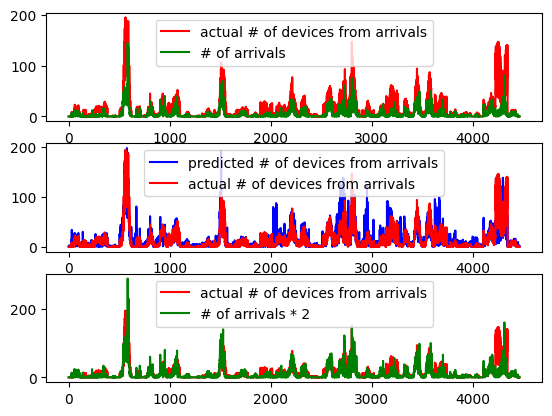

In [84]:
fig, ax = plt.subplots(3, 1)

ax[0].plot(y_np, color = 'r',  label = 'actual # of devices from arrivals')
ax[0].plot(arrivals_np, color = 'g',  label = '# of arrivals')
ax[0].legend()

ax[1].plot(pred_np, color = 'b', label = 'predicted # of devices from arrivals')
ax[1].plot(y_np, color = 'r', label = 'actual # of devices from arrivals')
ax[1].legend()

ax[2].plot(y_np, color = 'r',  label = 'actual # of devices from arrivals')
ax[2].plot(arrivals_np*2, color = 'g',  label = '# of arrivals * 2')
ax[2].legend()


In [85]:
loss_fn(pred, test_y)

tensor(182.0451, grad_fn=<MseLossBackward0>)

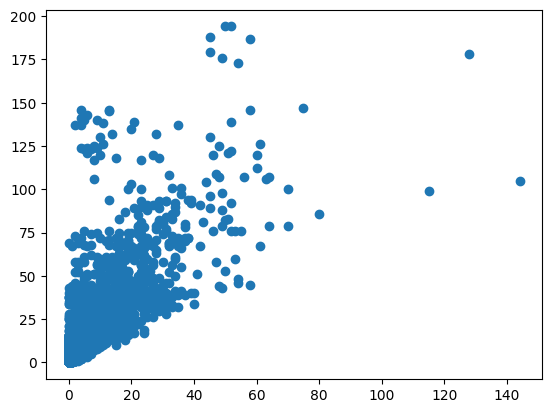

In [ ]:
plt.scatter(test_arrivals.detach().numpy(), test_y.detach().numpy())